# Load data from InfluxDB

In [8]:
%pip install influxdb-client


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "nIFNlhkdcuc8p7zn-zR5X0aHrMUhzEKEmcsne4YRugOvoWBTgzpeSl2SsBJp8buZJ-wR9jRXVzL7py6v23_KMw=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [10]:
# 1. Define the dynamic variables in the params dictionary
time_start = "-24h"
time_stop = "now()"
window = "1s"

# 2. Define the query using the v.variable syntax
query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(q|qd)_actual_joint_[0-5]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_ctrl_msgs = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
'''

# 3. Execute and return as a DataFrame
df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_ctrl_msgs = query_api.query_data_frame(query_ctrl_msgs)




/home/losmobilos3/Desktop/Engineering Digital Twins/UR3eDTCourse/.venv/lib/python3.11/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ur3e")
  |> range(start: -24h, stop: now())
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/inf

# Show data

In [11]:
print(df_ctrl_msgs.head())

    result  table                           _start  \
0  _result      0 2026-03-08 09:00:24.255716+00:00   
1  _result      0 2026-03-08 09:00:24.255716+00:00   
2  _result      0 2026-03-08 09:00:24.255716+00:00   
3  _result      0 2026-03-08 09:00:24.255716+00:00   
4  _result      0 2026-03-08 09:00:24.255716+00:00   

                             _stop                            _time _value  \
0 2026-03-09 09:00:24.255716+00:00 2026-03-09 08:23:10.866506+00:00   play   
1 2026-03-09 09:00:24.255716+00:00 2026-03-09 08:23:50.868501+00:00   play   
2 2026-03-09 09:00:24.255716+00:00 2026-03-09 08:24:30.869384+00:00   play   
3 2026-03-09 09:00:24.255716+00:00 2026-03-09 08:25:10.871167+00:00   play   
4 2026-03-09 09:00:24.255716+00:00 2026-03-09 08:25:50.872265+00:00   play   

     _field _measurement msg_type                 source  
0  msg_type    ctrl_msgs     play  data_recorder_service  
1  msg_type    ctrl_msgs     play  data_recorder_service  
2  msg_type    ctrl_msgs     

In [12]:
print(df_sensor_data.head())


    result  table                            _time  \
0  _result      0 2026-03-09 08:22:09.623099+00:00   
1  _result      0 2026-03-09 08:22:09.673046+00:00   
2  _result      0 2026-03-09 08:22:09.721727+00:00   
3  _result      0 2026-03-09 08:22:09.770690+00:00   
4  _result      0 2026-03-09 08:22:09.821098+00:00   

                            _start                            _stop  \
0 2026-03-08 09:00:23.264848+00:00 2026-03-09 09:00:23.264848+00:00   
1 2026-03-08 09:00:23.264848+00:00 2026-03-09 09:00:23.264848+00:00   
2 2026-03-08 09:00:23.264848+00:00 2026-03-09 09:00:23.264848+00:00   
3 2026-03-08 09:00:23.264848+00:00 2026-03-09 09:00:23.264848+00:00   
4 2026-03-08 09:00:23.264848+00:00 2026-03-09 09:00:23.264848+00:00   

  _measurement                 source  q_actual_joint_0  q_actual_joint_1  \
0  sensor_data  data_recorder_service     -9.453319e-08             -1.57   
1  sensor_data  data_recorder_service     -3.505391e-09             -1.57   
2  sensor_data  d

In [13]:
sensor_data_np = df_sensor_data.to_numpy()
start_msgs_timestamps = df_ctrl_msgs["_time"].to_list()

In [14]:
sensor_data_np.shape

(45235, 19)

In [15]:
sensor_data_np[0, :]

array(['_result', 0,
       Timestamp('2026-03-09 08:22:09.623099+0000', tz='UTC'),
       Timestamp('2026-03-08 09:00:23.264848+0000', tz='UTC'),
       Timestamp('2026-03-09 09:00:23.264848+0000', tz='UTC'),
       'sensor_data', 'data_recorder_service', -9.453319440258193e-08,
       -1.570000100606217, 1.5699998987370098, -1.569999756309897,
       -1.5699999947715153, 3.3581436523197966e-08, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0], dtype=object)

In [16]:
start_msgs_timestamps

[Timestamp('2026-03-09 08:23:10.866506+0000', tz='UTC'),
 Timestamp('2026-03-09 08:23:50.868501+0000', tz='UTC'),
 Timestamp('2026-03-09 08:24:30.869384+0000', tz='UTC'),
 Timestamp('2026-03-09 08:25:10.871167+0000', tz='UTC'),
 Timestamp('2026-03-09 08:25:50.872265+0000', tz='UTC'),
 Timestamp('2026-03-09 08:26:30.874611+0000', tz='UTC'),
 Timestamp('2026-03-09 08:27:10.873662+0000', tz='UTC'),
 Timestamp('2026-03-09 08:27:50.875701+0000', tz='UTC'),
 Timestamp('2026-03-09 08:28:30.877542+0000', tz='UTC'),
 Timestamp('2026-03-09 08:29:10.879582+0000', tz='UTC'),
 Timestamp('2026-03-09 08:29:50.880764+0000', tz='UTC'),
 Timestamp('2026-03-09 08:30:30.885483+0000', tz='UTC'),
 Timestamp('2026-03-09 08:31:10.884232+0000', tz='UTC'),
 Timestamp('2026-03-09 08:31:50.889826+0000', tz='UTC'),
 Timestamp('2026-03-09 08:32:30.888927+0000', tz='UTC'),
 Timestamp('2026-03-09 08:33:10.897705+0000', tz='UTC'),
 Timestamp('2026-03-09 08:33:50.892478+0000', tz='UTC'),
 Timestamp('2026-03-09 08:34:30

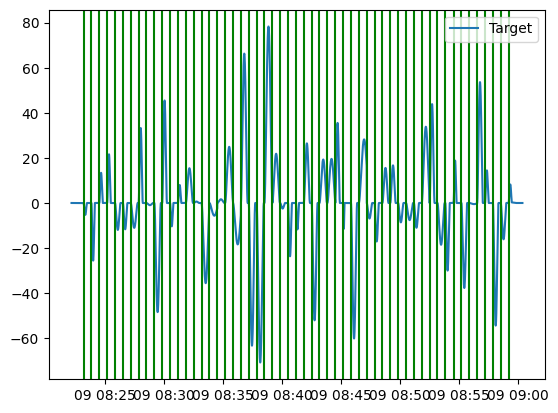

In [17]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, 2], sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for movement_start in start_msgs_timestamps:
    plt.axvline(movement_start, color="g")

plt.legend()

# Determine end of movements
From observing the PT mockup, we have determined that all joints take the same amount of time to move.

In [18]:
import copy
# Translate timestamps into indexes
start_indexes = []
start_timestamps = copy.deepcopy(start_msgs_timestamps)

for n in range(sensor_data_np.shape[0] - 1):
    time_at_n = sensor_data_np[n, 2]
    time_at_n_plus_1 = sensor_data_np[n+1, 2]
    if time_at_n <= start_timestamps[0] <= time_at_n_plus_1:
        start_indexes.append(n)
        start_timestamps.pop(0)
    if len(start_timestamps) == 0:
        break

In [19]:
start_indexes

[1219,
 2016,
 2812,
 3609,
 4406,
 5202,
 5999,
 6796,
 7593,
 8391,
 9188,
 9984,
 10780,
 11576,
 12372,
 13168,
 13963,
 14758,
 15554,
 16351,
 17147,
 17944,
 18740,
 19537,
 20332,
 21127,
 21922,
 22718,
 23515,
 24310,
 25107,
 25903,
 26698,
 27496,
 28292,
 29088,
 29884,
 30681,
 31478,
 32275,
 33072,
 33868,
 34665,
 35462,
 36259,
 37057,
 37854,
 38650,
 39445,
 40242,
 41038,
 41834,
 42629,
 43426,
 44221]

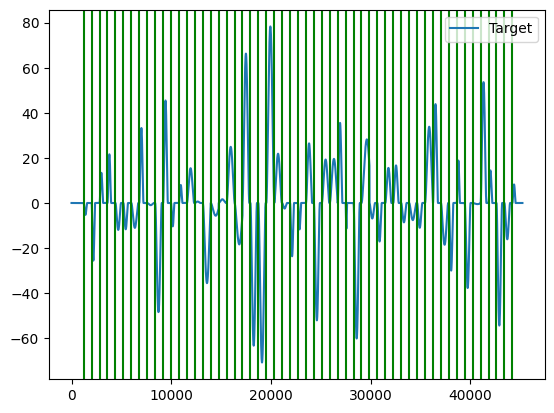

In [20]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i in start_indexes:
    plt.axvline(i, color="g")

plt.legend()

In [21]:
def determine_movement_ends(joint_vels: np.ndarray, start_indexes: list, threshold=1e-3, window=5):
    end_timestamps = []
    
    # Combine into a single speed since every joint finishes moving at the same time
    speed = np.linalg.norm(joint_vels, axis=1)
    
    for i in start_indexes:
        # Only look at data occurring after the start of this specific movement
        post_start_speed = speed[i:]
        
        # Find where speed drops below the threshold
        under_threshold = post_start_speed < threshold
        
        # To avoid mid-motion zero-crossings, ensure speed stays low for 'window' frames
        # We use a logical convolution to find a sequence of 'True' values
        is_settled = np.convolve(under_threshold, np.ones(window), mode='valid') == window
        
        # Find the first index where the 'settled' condition is met
        settled_indices = np.where(is_settled)[0]
        
        if settled_indices.size > 0:
            # We add 'ts' to get the global index, and 'window' isn't strictly 
            # necessary but helps point to the actual start of the stillness
            end_timestamps.append(i + settled_indices[0])
        else:
            # Fallback to end of array if no stop is detected
            end_timestamps.append(len(joint_vels) - 1)
            
    return end_timestamps

[1219, 2016, 2812, 3609, 4406, 5202, 5999, 6796, 7593, 8391, 9188, 9984, 10780, 11576, 12372, 13168, 13963, 14758, 15554, 16351, 17147, 17944, 18740, 19537, 20332, 21127, 21922, 22718, 23515, 24310, 25107, 25903, 26698, 27496, 28292, 29088, 29884, 30681, 31478, 32275, 33072, 33868, 34665, 35462, 36259, 37057, 37854, 38650, 39445, 40242, 41038, 41834, 42629, 43426, 44221]
[1571, 2368, 3175, 3981, 4969, 5670, 6706, 7220, 8282, 9054, 9667, 10328, 11135, 12306, 12928, 15498, 15498, 15498, 17837, 17837, 17837, 18604, 19476, 21104, 21104, 21624, 22328, 23033, 24143, 24914, 25868, 27174, 27174, 27645, 28920, 30454, 30454, 31124, 32097, 32829, 33621, 34599, 35197, 36764, 36764, 37791, 38310, 38964, 40030, 41619, 41619, 42211, 43198, 43997, 44546]


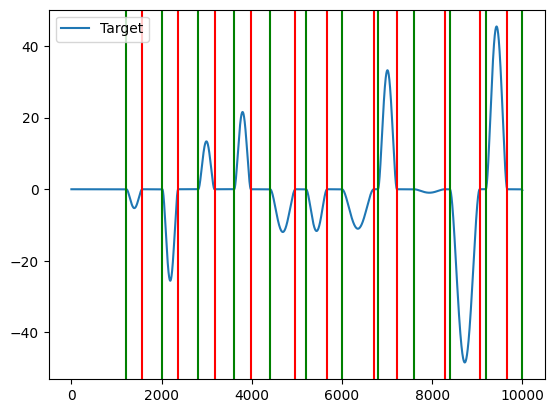

In [22]:
lower_bound = 0
upper_bound = 10000

joint_vels = sensor_data_np[:, -6:]
joint_vels = joint_vels.astype(np.float64)

end_indexes = determine_movement_ends(joint_vels, start_indexes)

print(start_indexes)
print(end_indexes)

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i, _ in enumerate(start_indexes):
    if lower_bound < start_indexes[i] < upper_bound:
        plt.axvline(start_indexes[i], color="g")
    if lower_bound < end_indexes[i] < upper_bound:
        plt.axvline(end_indexes[i], color="r")


plt.legend()

# Declaring data needed for training

We want to train a model to predict the time it takes to do a certain movement. Thus we now need to extract, the time a movement takes, and the start and end position

In [23]:
# Extract time
# This is easy as it is just the difference between the start and end timesteps of movements
start_positions = []
end_positions = []
movement_time = []

joint_positions = sensor_data_np[:, -12:-6]

for i, _ in enumerate(start_indexes):
    # Determine time taken
    time_taken = sensor_data_np[end_indexes[i], 2] - sensor_data_np[start_indexes[i], 2]
    movement_time.append(time_taken.total_seconds()) # save time taken in seconds

    # Extract start and end pos
    start_pos = joint_positions[start_indexes[i], :]
    start_positions.append(start_pos)

    end_pos = joint_positions[end_indexes[i], :]
    end_positions.append(end_pos)


print(f"{movement_time=}\n")
print(f"{start_positions=}\n")
print(f"{end_positions=}\n")

movement_time=[17.666415, 17.710013, 18.206816, 18.672235, 28.26888, 23.506379, 35.483618, 21.282825, 34.551645, 33.250883, 24.071754, 17.297908, 17.850842, 36.652944, 27.981267, 117.155963, 77.185985, 37.200132, 114.645254, 74.625679, 34.639812, 33.171233, 36.980722, 78.825138, 38.850831, 24.992696, 20.397759, 15.84671, 31.584374, 30.317481, 38.237225, 63.819552, 23.856365, 7.479986, 31.550662, 68.645694, 28.628885, 22.253891, 31.023239, 27.795782, 27.597629, 36.686961, 26.691812, 65.280524, 25.294491, 36.872275, 22.910086, 15.803094, 29.394756, 69.180135, 29.183464, 18.967021, 28.594262, 28.703069, 35.978053]

start_positions=[array([-1.2926837187917185e-06, -1.569995191027, 1.5699978848251912,
       -1.569994767597106, -1.5700026911301288, 3.970057626803097e-06],
      dtype=object), array([-0.273941060749949, -19.16601347064811, -1.4056308600170113,
       -4.074003046890885, -17.275265482476748, -2.8108371256204747],
      dtype=object), array([9.87934807391203, -1.56029958139912

In [24]:
start_positions[0]

array([-1.2926837187917185e-06, -1.569995191027, 1.5699978848251912,
       -1.569994767597106, -1.5700026911301288, 3.970057626803097e-06],
      dtype=object)

In [25]:
end_positions[0]

array([-0.2739424916338492, -19.166013631373147, -1.4056332370886524,
       -4.074005999113509, -17.27526643160836, -2.810835345612519],
      dtype=object)

# Plot of correlation between the max distance a joint has to move and the time the movement takes.

In [26]:
max_position_diff = []

for i, _ in enumerate(start_positions):
    max_position_diff.append(np.max(np.abs(end_positions[i] - start_positions[i])))

max_position_diff

[17.596018440346146,
 17.605711718328653,
 18.17001404014526,
 18.654789517482193,
 28.660908741855778,
 23.666874255217813,
 36.1992528320022,
 21.404069024321785,
 35.262214392366985,
 33.900007334159525,
 24.2490300825576,
 17.17591082779008,
 17.763967023927865,
 37.42514649331337,
 28.32055494034585,
 22.230840299463324,
 46.251994112249534,
 37.89223227545482,
 40.649957581850934,
 48.12717130585615,
 35.33332711636875,
 33.74584155733842,
 37.72894725275919,
 53.40138598074351,
 39.61083614723673,
 25.21930642238837,
 20.428731637265766,
 15.623407561628495,
 32.049251848918075,
 30.81497908682188,
 39.036163451738474,
 39.98610255737985,
 24.043802749729483,
 6.975413316182128,
 32.052406359166525,
 20.040471100262867,
 29.03894815400627,
 22.372237633166755,
 31.595177527791872,
 28.17462040520644,
 27.93216931483792,
 37.44178542849296,
 27.029583594393472,
 41.40875773658095,
 25.63040107352614,
 37.61221840361437,
 23.058174946425222,
 15.61271129407785,
 29.796214161468995

Text(0.5, 0, 'Max angle difference (rad)')

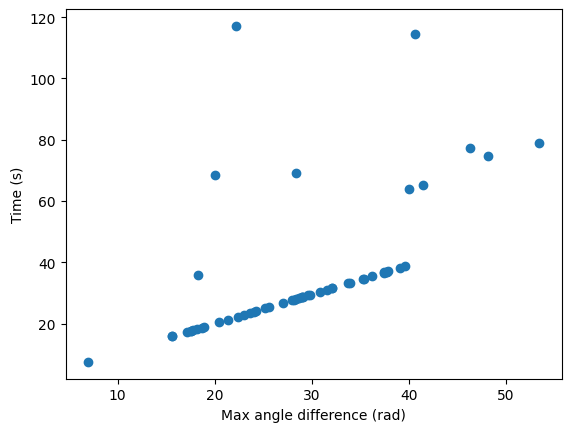

In [27]:
plt.scatter(max_position_diff, movement_time)
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")

## Proposing model

It seems we have a nice linear relationship. A linear regression model will do fine for fitting here!

Now we use the following approach for fitting the data:

$$Ax = b$$
$$\Updownarrow$$
$$x = A^{-1}b$$

Here $A$ contains the max joint position differences and a constant $1$, and $b$ contains the movement time.

In [28]:
A = np.vander(max_position_diff, 2)
b = np.array(movement_time)

x = np.linalg.pinv(A) @ b

x

array([ 1.37211621, -3.60945777])

We can now use the found coefficients $x_0$ and $x_1$ to make a model:

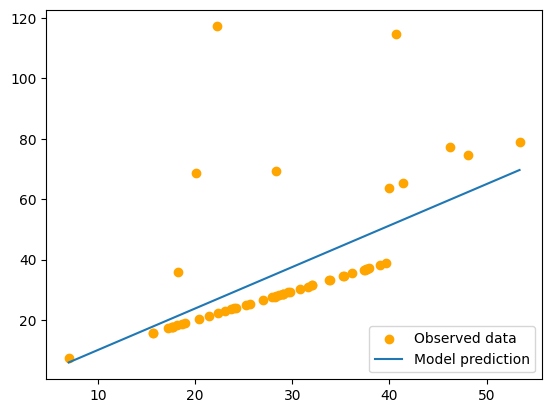

In [ ]:
angle_space = np.linspace(np.min(max_position_diff), np.max(max_position_diff), 100)

# Feed through model
def linear_reg_model(n: np.ndarray, x: np.ndarray):
    n_vander = np.vander(n, 2)
    return n_vander @ x

time_spent_prediction = linear_reg_model(angle_space, x)

plt.scatter(max_position_diff, movement_time, color="orange", label="Observed data")
plt.plot(angle_space, time_spent_prediction, label="Model prediction")
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")
plt.legend()